In [2]:
import json, re, os, collections, csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

plt.rcParams['figure.facecolor'] = '#0f1829'
plt.rcParams['axes.facecolor']   = '#162035'
plt.rcParams['axes.edgecolor']   = '#1e2d45'
plt.rcParams['text.color']       = '#e2e8f0'
plt.rcParams['axes.labelcolor']  = '#94a3b8'
plt.rcParams['xtick.color']      = '#94a3b8'
plt.rcParams['ytick.color']      = '#94a3b8'
plt.rcParams['grid.color']       = '#1e2d45'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['font.family']      = 'monospace'
ACCENT = ['#00d4ff','#7c3aed','#10b981','#f59e0b','#ef4444','#ec4899','#6366f1','#14b8a6','#84cc16','#f97316']

FILE = 'biostars_db.csv'


## 1. Load Raw Data

In [3]:
df_raw = pd.read_csv(FILE, encoding='utf-8', on_bad_lines='skip')
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
print(f'\nNull counts:')
print(df_raw.isnull().sum().to_string())
print(f'\nSample row:')
display(df_raw.head(2))

Shape: (9299, 8)
Columns: ['question', 'answer', 'tags', 'accepted', 'score', 'url', 'reviewer_comment', 'reviewer_score']

Null counts:
question               0
answer                 0
tags                   0
accepted               0
score                  0
url                    0
reviewer_comment    9299
reviewer_score      9299

Sample row:


,question,answer,tags,accepted,score,url,reviewer_comment,reviewer_score
0,"Hi everyone, I'm gathering course materials fo...",A lot of material was added to YouTube by many...,"course,teaching;metagenome",False,6,https://www.biostars.org/p/480436/,NaN,NaN
1,"Hello, I ran a binning tool and assessed compl...",Bin completeness and contamination in CheckM a...,"metagenomics,bins,metagenome;metagenome",True,2,https://www.biostars.org/p/9526318/,NaN,NaN


In [4]:
df_raw['accepted'].value_counts()

accepted
False    5254
True     4045
Name: count, dtype: int64

## 2. Cleaning Pipeline

In [5]:
df = df_raw.copy()


# Clean text
def clean(t):
    if pd.isna(t): return ''
    t = str(t).replace('\u200b','').replace('\xa0',' ')
    return re.sub(r'\s+', ' ', t).strip()

df['question'] = df['question'].apply(clean)
df['answer']   = df['answer'].apply(clean)
df['tags']     = df['tags'].apply(clean)

# Score to int
if 'score' in df.columns:
    df['score'] = pd.to_numeric(df['score'].squeeze(), errors='coerce').fillna(0).astype(int)
else:
    df['score'] = 0

# Accepted to bool
df['accepted'] = df['accepted'].apply(lambda x: str(x).strip().lower() == 'true')

before = len(df)
removed_log = collections.Counter()

# Remove empty question or answer
mask_empty = (df['question'].str.len() < 10) | (df['answer'].str.len() < 10)
removed_log['empty_question_or_answer'] = mask_empty.sum()
df = df[~mask_empty]

# Remove duplicates on question
df['q_key'] = df['question'].str.lower().str[:80]
dup_mask = df.duplicated(subset='q_key', keep='first')
removed_log['duplicate_question'] = dup_mask.sum()
df = df[~dup_mask].drop(columns='q_key')

# Remove very short answers
df['ans_words'] = df['answer'].apply(lambda x: len(x.split()))
short_mask = df['ans_words'] < 8
removed_log['answer_too_short'] = short_mask.sum()
df = df[~short_mask]

print(f'\nCleaning Summary:')
print(f'  Before : {before:,}')
print(f'  After  : {len(df):,}')
print(f'  Removed: {before - len(df):,}')
for k,v in removed_log.items():
    print(f'    {k:35s}: {v}')


Cleaning Summary:
  Before : 9,299
  After  : 9,166
  Removed: 133
    empty_question_or_answer           : 0
    duplicate_question                 : 5
    answer_too_short                   : 128


## 3. Basic Statistics

In [6]:
df['q_words']   = df['question'].apply(lambda x: len(x.split()))
df['ans_words']  = df['answer'].apply(lambda x: len(x.split()))

print('=== QUESTION STATS ===')
print(df['q_words'].describe().to_string())
print('\n=== ANSWER STATS ===')
print(df['ans_words'].describe().to_string())
print('\n=== SCORE STATS ===')
print(df['score'].describe().to_string())
print(f'\nAccepted answers : {df["accepted"].sum():,} ({df["accepted"].mean()*100:.1f}%)')
print(f'Score >= 2       : {(df["score"]>=2).sum():,} ({(df["score"]>=2).mean()*100:.1f}%)')
print(f'Score >= 5       : {(df["score"]>=5).sum():,} ({(df["score"]>=5).mean()*100:.1f}%)')

=== QUESTION STATS ===
count    9166.000000
mean      155.374864
std       152.245579
min         8.000000
25%        70.000000
50%       114.000000
75%       188.000000
max      2330.000000

=== ANSWER STATS ===
count    9166.000000
mean      105.001527
std       103.151000
min         8.000000
25%        39.000000
50%        74.000000
75%       134.000000
max      1351.000000

=== SCORE STATS ===
count    9166.000000
mean        3.857081
std         4.792005
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max       172.000000

Accepted answers : 3,976 (43.4%)
Score >= 2       : 8,497 (92.7%)
Score >= 5       : 1,902 (20.8%)


Sources dans le dataset :
  biostars.org                            : 9,166 (100.0%)


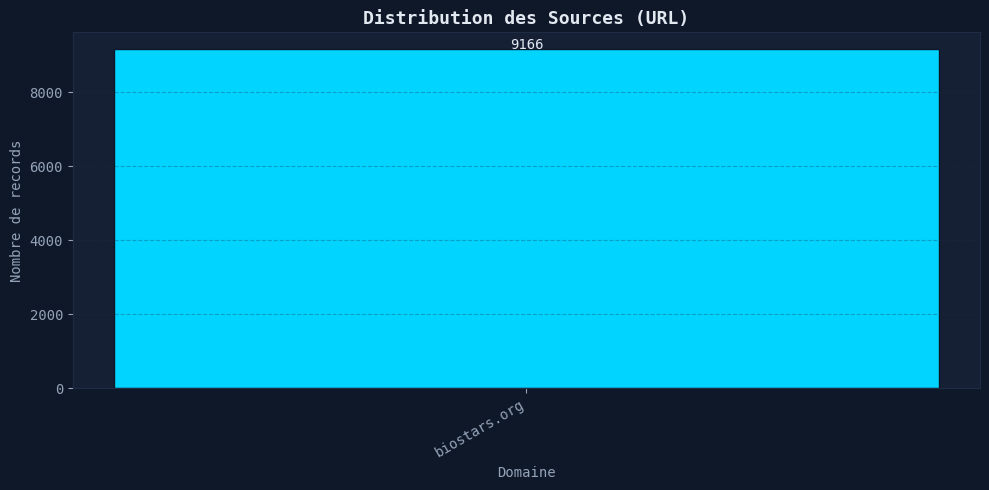

In [7]:
import re 
domains = []
for url in df['url']:
    match = re.search(r'https?://(?:www\.)?([^/]+)', str(url))
    if match:
        domains.append(match.group(1))
    else:
        domains.append('unknown')

domain_counts = collections.Counter(domains)
print("Sources dans le dataset :")
for domain, count in domain_counts.most_common():
    print(f"  {domain:40s}: {count:,} ({count/len(df)*100:.1f}%)")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1829')
labels, vals = zip(*domain_counts.most_common(10))
bars = ax.bar(labels, vals, color=ACCENT[:len(labels)], edgecolor='#0f1829')
ax.set_title('Distribution des Sources (URL)', color='#e2e8f0', fontsize=13, fontweight='bold')
ax.set_xlabel('Domaine', fontsize=10)
ax.set_ylabel('Nombre de records', fontsize=10)
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(val), ha='center', color='#e2e8f0', fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Score & Quality Distribution

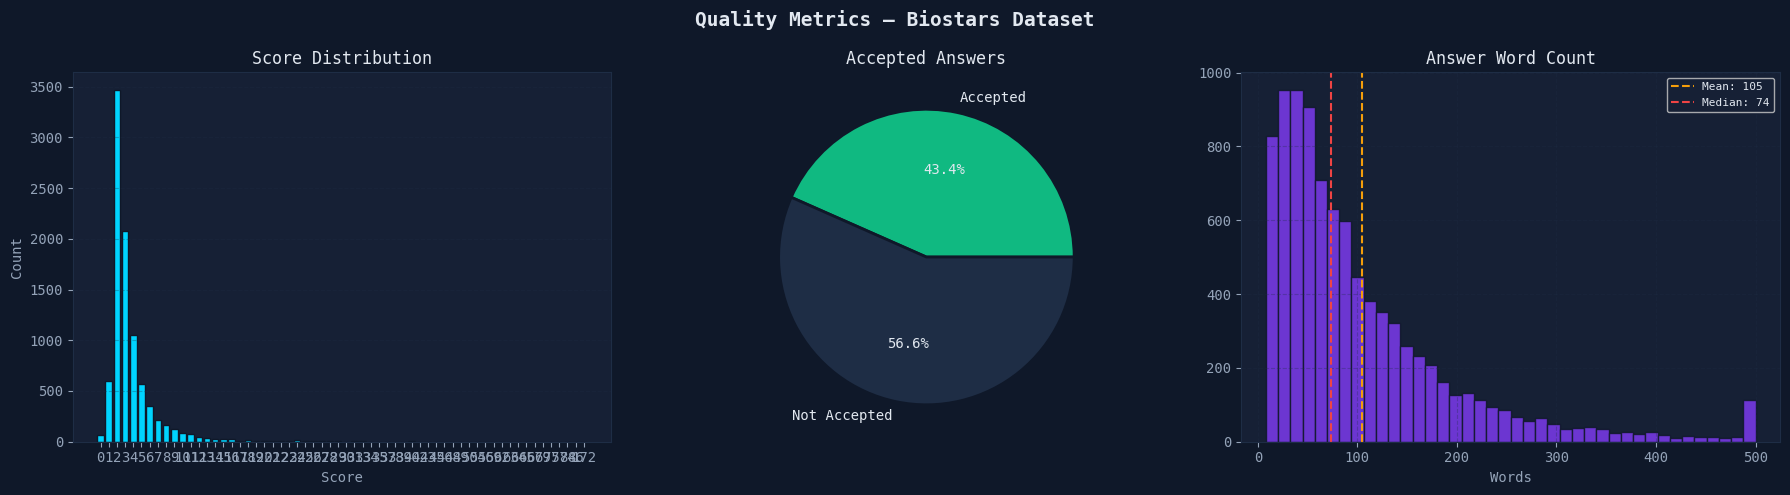

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1829')
fig.suptitle('Quality Metrics — Biostars Dataset', color='#e2e8f0', fontsize=14, fontweight='bold')

# Score distribution
score_counts = df['score'].value_counts().sort_index()
axes[0].bar(score_counts.index.astype(str), score_counts.values, color='#00d4ff', edgecolor='#0f1829')
axes[0].set_title('Score Distribution', color='#e2e8f0')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].grid(True, axis='y', alpha=0.3)

# Accepted pie
axes[1].pie(
    [df['accepted'].sum(), (~df['accepted']).sum()],
    labels=['Accepted', 'Not Accepted'],
    colors=['#10b981','#1e2d45'], autopct='%1.1f%%',
    textprops={'color':'#e2e8f0'}, wedgeprops={'edgecolor':'#0f1829','linewidth':2}
)
axes[1].set_title('Accepted Answers', color='#e2e8f0')

# Word count
axes[2].hist(df['ans_words'].clip(upper=500), bins=40, color='#7c3aed', edgecolor='#0f1829', alpha=0.85)
axes[2].set_title('Answer Word Count', color='#e2e8f0')
axes[2].set_xlabel('Words')
axes[2].axvline(df['ans_words'].mean(), color='#f59e0b', linestyle='--', label=f'Mean: {df["ans_words"].mean():.0f}')
axes[2].axvline(df['ans_words'].median(), color='#ef4444', linestyle='--', label=f'Median: {df["ans_words"].median():.0f}')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

## 5. Tag Analysis

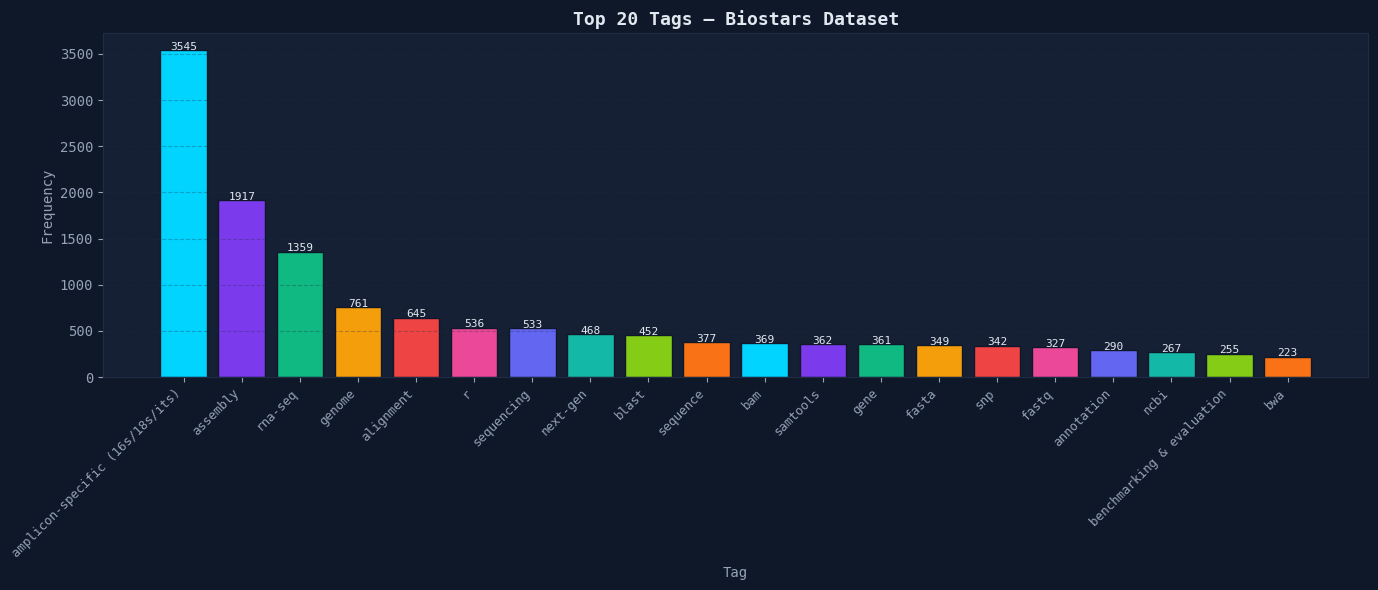

In [9]:
all_tags = []
for t in df['tags']:
    parts = re.split(r'[,;]', str(t))
    all_tags.extend([p.strip().lower() for p in parts if p.strip()])

# Remove generic noise
GENERIC_TAGS = {'metagenome','tag1','tag2','','na','none'}
all_tags = [t for t in all_tags if t not in GENERIC_TAGS]

tag_counts = collections.Counter(all_tags).most_common(20)
tag_labels, tag_vals = zip(*tag_counts)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f1829')
colors = [ACCENT[i % len(ACCENT)] for i in range(len(tag_labels))]
bars = ax.bar(tag_labels, tag_vals, color=colors, edgecolor='#0f1829')
ax.set_title('Top 20 Tags — Biostars Dataset', color='#e2e8f0', fontsize=13, fontweight='bold')
ax.set_xlabel('Tag', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
for bar, val in zip(bars, tag_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(val), ha='center', color='#e2e8f0', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [10]:
# ── Cellule : Filtre métagénomique — AVANT détection des catégories ──

METAGENOMIC_KEYWORDS = [
    # Métagénomique directe
    'metagenom','microbiome','microbiota','shotgun',
    'assembly','contig','scaffold','binning','metabat',
    'maxbin','checkm','metaspades','megahit','kraken',
    'metaphlan','bracken', 'human genome'
    # ADN / Séquençage
    'dna','genome','genomic','sequencing','fastq','fasta',
    'reads','illumina','nanopore','paired-end',
    # Taxonomie
    'taxonomy','16s','amplicon','otu','asv','phylogenetic',
    'bacteria','archaea','virus','fungi','prokaryote',
    # Outils pipeline
    'fastqc','trimmomatic','fastp','bowtie','bwa',
    'samtools','prokka','prodigal','annotation'
]

NON_META_KEYWORDS = [
    'rna-seq','rnaseq','transcriptom','mrna',
    'expression','deseq','edger','kallisto',
    'chip-seq','atac-seq','gwas',
    'somatic mutation','variant calling','snp calling'
]

def is_metagenomic(row):
    text = (str(row['question']) + ' ' +
            str(row['answer']) + ' ' +
            str(row['tags'])).lower()
    has_meta     = any(kw in text for kw in METAGENOMIC_KEYWORDS)
    has_non_meta = any(kw in text for kw in NON_META_KEYWORDS)
    return has_meta and not has_non_meta

before = len(df)
df['is_metagenomic'] = df.apply(is_metagenomic, axis=1)

meta_count     = df['is_metagenomic'].sum()
non_meta_count = (~df['is_metagenomic']).sum()

print(f"Avant filtre métagénomique : {before:,}")
print(f"Records métagénomique      : {meta_count:,} ({meta_count/before*100:.1f}%)")
print(f"Records hors scope         : {non_meta_count:,} ({non_meta_count/before*100:.1f}%)")


df = df[df['is_metagenomic']].copy().reset_index(drop=True)
print(f"\n df filtré final : {len(df):,} records")
print("→ Toutes les cellules suivantes (catégories, exports) travaillent sur ce df propre")


Avant filtre métagénomique : 9,166
Records métagénomique      : 5,722 (62.4%)
Records hors scope         : 3,444 (37.6%)

 df filtré final : 5,722 records
→ Toutes les cellules suivantes (catégories, exports) travaillent sur ce df propre


## 6. Category Detection

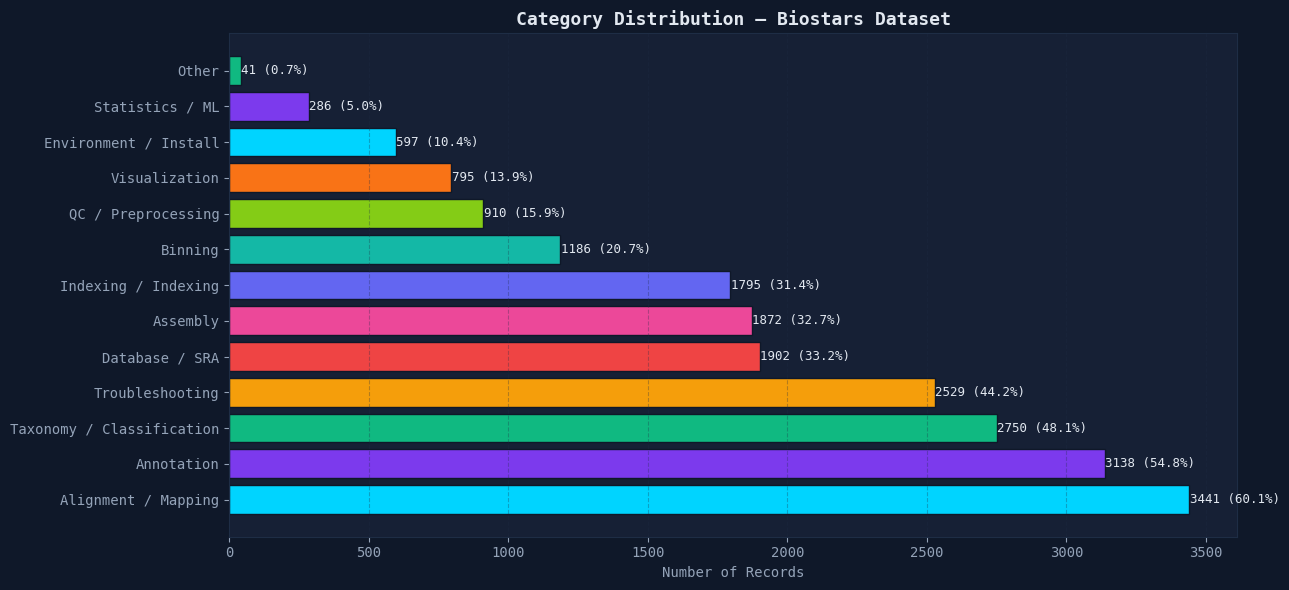


Category breakdown:
  Alignment / Mapping                :  3441 (60.1%)
  Annotation                         :  3138 (54.8%)
  Taxonomy / Classification          :  2750 (48.1%)
  Troubleshooting                    :  2529 (44.2%)
  Database / SRA                     :  1902 (33.2%)
  Assembly                           :  1872 (32.7%)
  Indexing / Indexing                :  1795 (31.4%)
  Binning                            :  1186 (20.7%)
  QC / Preprocessing                 :   910 (15.9%)
  Visualization                      :   795 (13.9%)
  Environment / Install              :   597 (10.4%)
  Statistics / ML                    :   286 (5.0%)
  Other                              :    41 (0.7%)


In [11]:
CATEGORIES = {
    'Assembly':              ['assembly','assemble','spades','megahit','contig','scaffold','velvet'],
    'Binning':               ['bin','metabat','maxbin','checkm','completeness','contamination','binning'],
    'QC / Preprocessing':   ['fastqc','trimmomatic','fastp','quality','deduplication','adapter','trim','bbduk'],
    'Taxonomy / Classification': ['classif','taxonom','kraken','metaphlan','bracken','genus','species','16s','otu','asv'],
    'Alignment / Mapping':   ['bowtie','bwa','mapping','align','bam','sam','read map','minimap'],
    'Database / SRA':        ['database','ncbi','sra','metadata','download','ebi','genbank'],
    'Annotation':            ['annot','prokka','prodigal','protein','gene','function','kegg','cog'],
    'Indexing / Indexing':   ['salmon','index','kallisto','hisat','star'],
    'Visualization':         ['visual','plot','r package','ggplot','qiime','diversity','alpha','beta'],
    'Statistics / ML':       ['statistic','machine learning','random forest','pca','umap','differential','deseq'],
    'Troubleshooting':       ['error','warning','fail','crash','bug','issue','problem','fix','not work','cannot'],
    'Environment / Install': ['conda','mamba','install','environment','docker','singularity','bioconda'],
}

def detect_cats(row):
    text = (str(row['question']) + ' ' + str(row['answer']) + ' ' + str(row['tags'])).lower()
    found = [cat for cat, kws in CATEGORIES.items() if any(k in text for k in kws)]
    return found if found else ['Other']

df['categories'] = df.apply(detect_cats, axis=1)
df['cat_count']  = df['categories'].apply(len)

all_cats = [c for cats in df['categories'] for c in cats]
cat_counts = collections.Counter(all_cats)
cats_sorted = sorted(cat_counts.items(), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1829')
labels, vals = zip(*cats_sorted)
colors = [ACCENT[i % len(ACCENT)] for i in range(len(labels))]
bars = ax.barh(labels, vals, color=colors, edgecolor='#0f1829')
ax.set_title('Category Distribution — Biostars Dataset', color='#e2e8f0', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Records', fontsize=10)
for bar, val in zip(bars, vals):
    pct = val/len(df)*100
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2, f'{val} ({pct:.1f}%)', va='center', color='#e2e8f0', fontsize=9)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()

plt.show()

print('\nCategory breakdown:')
for cat, cnt in cats_sorted:
    print(f'  {cat:35s}: {cnt:5d} ({cnt/len(df)*100:.1f}%)')

## 7. Bash / Code Detection in Answers

Answers with code/bash commands : 2,059 (36.0%)
Answers conceptual only         : 3,663 (64.0%)
Code + Accepted (best quality)  : 966 (16.9%)


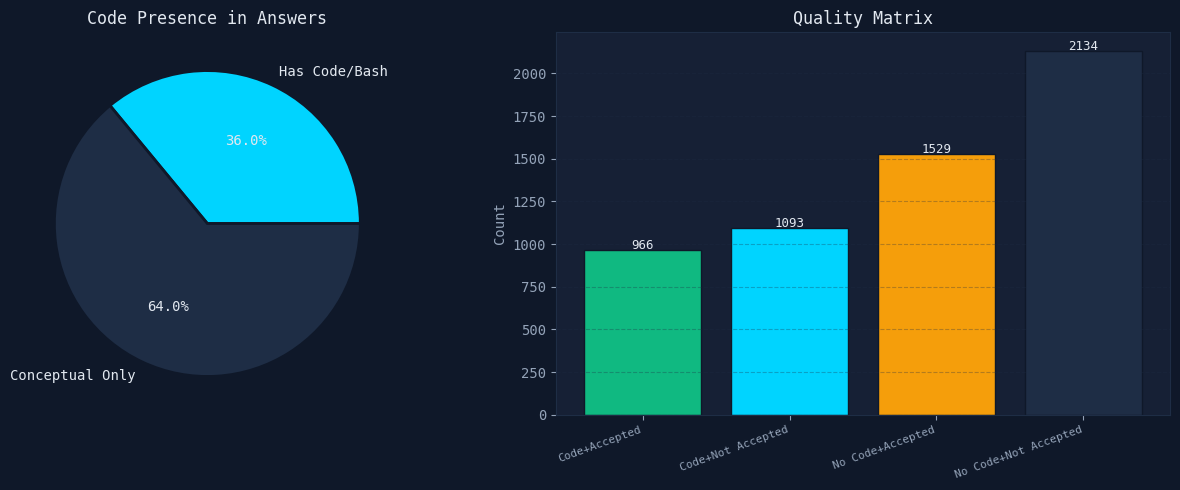

In [12]:
BASH_PATTERN = re.compile(
    r'(fastqc|trimmomatic|metaspades|spades|maxbin|checkm|fastp|bowtie|samtools'
    r'|kraken|micromamba|conda|bash|mkdir|chmod|python |import |\$\s|\./'
    r'|\.sh\b|\.py\b|--\w+|/usr|/home|/tmp|/data|sudo|apt|pip install)',
    re.IGNORECASE
)

df['has_code'] = df['answer'].apply(lambda x: bool(BASH_PATTERN.search(str(x))))

print(f'Answers with code/bash commands : {df["has_code"].sum():,} ({df["has_code"].mean()*100:.1f}%)')
print(f'Answers conceptual only         : {(~df["has_code"]).sum():,} ({(~df["has_code"]).mean()*100:.1f}%)')

# Cross: code AND accepted
code_accepted = (df['has_code'] & df['accepted']).sum()
print(f'Code + Accepted (best quality)  : {code_accepted:,} ({code_accepted/len(df)*100:.1f}%)')

# Stacked bar: accepted vs not, by code presence
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1829')

# Code vs No code
axes[0].pie(
    [df['has_code'].sum(), (~df['has_code']).sum()],
    labels=['Has Code/Bash','Conceptual Only'],
    colors=['#00d4ff','#1e2d45'], autopct='%1.1f%%',
    textprops={'color':'#e2e8f0'}, wedgeprops={'edgecolor':'#0f1829','linewidth':2}
)
axes[0].set_title('Code Presence in Answers', color='#e2e8f0', fontsize=12)

# Code quality matrix
groups = ['Code+Accepted','Code+Not Accepted','No Code+Accepted','No Code+Not Accepted']
group_vals = [
    (df['has_code'] & df['accepted']).sum(),
    (df['has_code'] & ~df['accepted']).sum(),
    (~df['has_code'] & df['accepted']).sum(),
    (~df['has_code'] & ~df['accepted']).sum(),
]
group_colors = ['#10b981','#00d4ff','#f59e0b','#1e2d45']
bars = axes[1].bar(groups, group_vals, color=group_colors, edgecolor='#0f1829')
axes[1].set_title('Quality Matrix', color='#e2e8f0', fontsize=12)
axes[1].set_ylabel('Count')
plt.xticks(rotation=20, ha='right', fontsize=8)
for bar, val in zip(bars, group_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val), ha='center', color='#e2e8f0', fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

## 8. Top Keywords in Questions & Answers

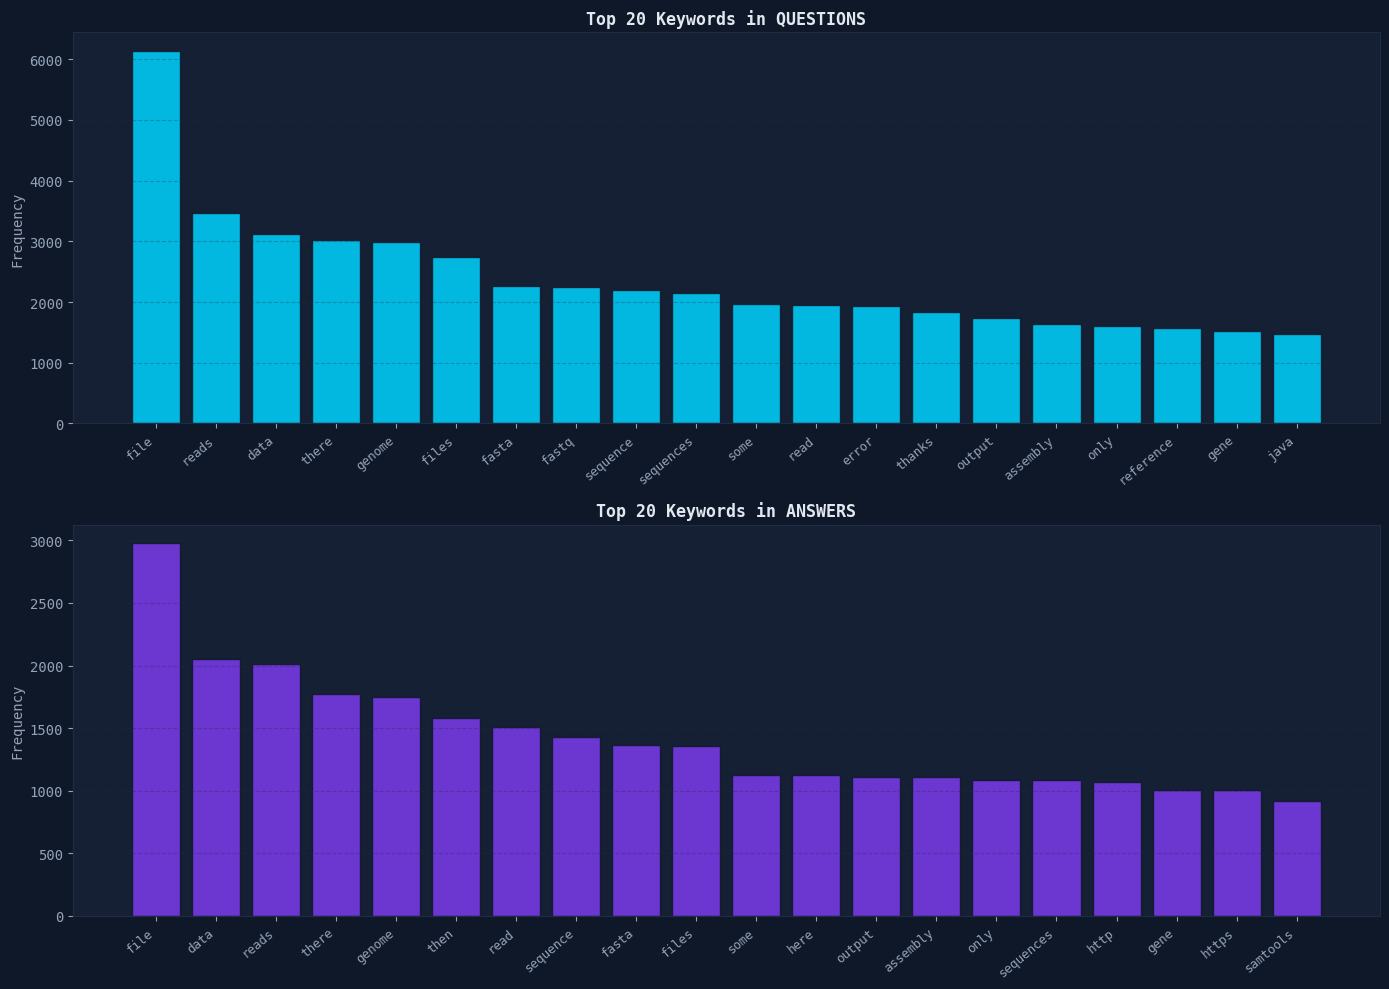

In [13]:
STOPWORDS = set(['the','a','an','of','in','to','and','is','are','that','this','for',
                 'with','on','by','as','at','be','it','its','from','or','which','can',
                 'also','these','their','they','them','not','into','how','do','does',
                 'what','why','when','where','such','both','through','between','while',
                 'well','more','have','has','had','been','during','was','were','will',
                 'would','could','should','may','might','thus','than','each','other',
                 'same','using','used','use','want','need','help','trying','just','like',
                 'your','our','you','we','my','me','hi','hello','anyone','anyone','know'])

q_words, a_words = [], []
for _, row in df.iterrows():
    for w in re.findall(r'\b[a-z]{4,}\b', str(row['question']).lower()):
        if w not in STOPWORDS: q_words.append(w)
    for w in re.findall(r'\b[a-z]{4,}\b', str(row['answer']).lower()):
        if w not in STOPWORDS: a_words.append(w)

q_freq = collections.Counter(q_words).most_common(20)
a_freq = collections.Counter(a_words).most_common(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('#0f1829')

for ax, freq, title, color in [
    (axes[0], q_freq, 'Top 20 Keywords in QUESTIONS', '#00d4ff'),
    (axes[1], a_freq, 'Top 20 Keywords in ANSWERS', '#7c3aed')
]:
    labels, vals = zip(*freq)
    ax.bar(labels, vals, color=color, alpha=0.85, edgecolor='#0f1829')
    ax.set_title(title, color='#e2e8f0', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.grid(True, axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)

plt.tight_layout()

plt.show()

## 9. Answer Length by Category

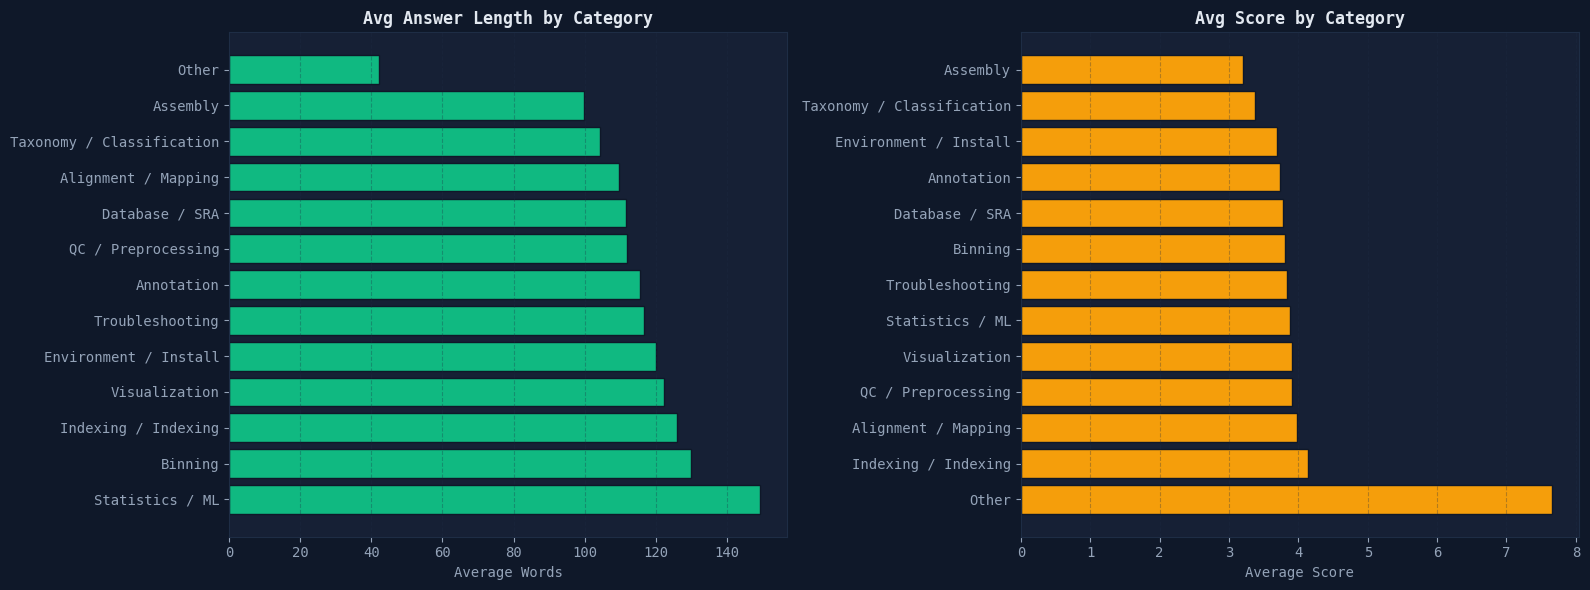

In [14]:
# Flatten: one row per category assignment
rows = []
for _, row in df.iterrows():
    for cat in row['categories']:
        rows.append({'category': cat, 'ans_words': row['ans_words'], 'score': row['score'], 'accepted': row['accepted']})
df_flat = pd.DataFrame(rows)

cat_avg = df_flat.groupby('category')['ans_words'].mean().sort_values(ascending=False)
cat_score = df_flat.groupby('category')['score'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1829')

axes[0].barh(cat_avg.index, cat_avg.values, color='#10b981', edgecolor='#0f1829')
axes[0].set_title('Avg Answer Length by Category', color='#e2e8f0', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Words')
axes[0].grid(True, axis='x', alpha=0.3)

axes[1].barh(cat_score.index, cat_score.values, color='#f59e0b', edgecolor='#0f1829')
axes[1].set_title('Avg Score by Category', color='#e2e8f0', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Score')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

## 10. Filter: High-Quality Records for Agent Training

In [15]:
# High quality = accepted OR score >= 2, AND has some content
hq = df[(df['accepted'] | (df['score'] >= 2)) & (df['ans_words'] >= 20)].copy()
hq_code = hq[hq['has_code']].copy()

print(f'Total cleaned records             : {len(df):,}')
print(f'High quality (accepted|score>=2)  : {len(hq):,} ({len(hq)/len(df)*100:.1f}%)')
print(f'High quality + has code/bash      : {len(hq_code):,} ({len(hq_code)/len(df)*100:.1f}%)')
print()
print('Category breakdown in HIGH QUALITY records:')
hq_cats = [c for cats in hq['categories'] for c in cats]
for cat, cnt in collections.Counter(hq_cats).most_common():
    print(f'  {cat:35s}: {cnt:5d}')

Total cleaned records             : 5,722
High quality (accepted|score>=2)  : 5,223 (91.3%)
High quality + has code/bash      : 1,950 (34.1%)

Category breakdown in HIGH QUALITY records:
  Alignment / Mapping                :  3198
  Annotation                         :  2926
  Taxonomy / Classification          :  2526
  Troubleshooting                    :  2379
  Database / SRA                     :  1779
  Assembly                           :  1716
  Indexing / Indexing                :  1683
  Binning                            :  1110
  QC / Preprocessing                 :   853
  Visualization                      :   734
  Environment / Install              :   558
  Statistics / ML                    :   273
  Other                              :    31


## 11. Final KPI Summary

In [16]:
print('='*55)
print('   BIOSTARS DATASET — FINAL KPI SUMMARY')
print('='*55)
print(f'  Total records (raw)           : {len(df_raw):,}')
print(f'  After cleaning                : {len(df):,}')
print(f'  Removed                       : {len(df_raw)-len(df):,} ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)')
print()
print(f'  Avg question length           : {df["q_words"].mean():.1f} words')
print(f'  Avg answer length             : {df["ans_words"].mean():.1f} words')
print(f'  Median answer length          : {df["ans_words"].median():.1f} words')
print()
print(f'  Accepted answers              : {df["accepted"].sum():,} ({df["accepted"].mean()*100:.1f}%)')
print(f'  Score >= 2                    : {(df["score"]>=2).sum():,} ({(df["score"]>=2).mean()*100:.1f}%)')
print(f'  Answers with bash/code        : {df["has_code"].sum():,} ({df["has_code"].mean()*100:.1f}%)')
print(f'  High quality + code           : {len(hq_code):,} ({len(hq_code)/len(df)*100:.1f}%)')
print()
print(f'  Top 3 categories:')
for cat, cnt in cats_sorted[:3]:
    print(f'    {cat:35s}: {cnt:5d} ({cnt/len(df)*100:.1f}%)')
print()

print(f'    → Real metagenomics domain questions')
print(f'    → {df["has_code"].mean()*100:.1f}% answers contain real bash commands')
print(f'    → Diverse tool coverage (CheckM, MetaSPAdes, Bowtie...)')
print()
print('  ⚠  GAPS:')
print(f'    → Needs reformatting to instruction/input/output')
print(f'    → Only {df["accepted"].mean()*100:.1f}% accepted — quality filtering needed')
print(f'    → No Micromamba-specific examples found')
print('='*55)

   BIOSTARS DATASET — FINAL KPI SUMMARY
  Total records (raw)           : 9,299
  After cleaning                : 5,722
  Removed                       : 3,577 (38.5%)

  Avg question length           : 146.4 words
  Avg answer length             : 100.4 words
  Median answer length          : 70.0 words

  Accepted answers              : 2,495 (43.6%)
  Score >= 2                    : 5,291 (92.5%)
  Answers with bash/code        : 2,059 (36.0%)
  High quality + code           : 1,950 (34.1%)

  Top 3 categories:
    Alignment / Mapping                :  3441 (60.1%)
    Annotation                         :  3138 (54.8%)
    Taxonomy / Classification          :  2750 (48.1%)

    → Real metagenomics domain questions
    → 36.0% answers contain real bash commands
    → Diverse tool coverage (CheckM, MetaSPAdes, Bowtie...)

  ⚠  GAPS:
    → Needs reformatting to instruction/input/output
    → Only 43.6% accepted — quality filtering needed
    → No Micromamba-specific examples found


## 12. Export Clean + High Quality Subsets

In [ ]:
# ── Cellule : Export 3 datasets finaux JSONL ──

def export_jsonl(dataframe, path):
    with open(path, 'w', encoding='utf-8') as f:
        for _, row in dataframe.iterrows():
            f.write(json.dumps({
                'input':  row['question'],
                'output': row['answer']
            }, ensure_ascii=False) + '\n')
    return len(dataframe)


# ── 2.hq
hq_code_not_in_hq = df[
    (df['has_code']) &
    (~df.index.isin(hq.index))
].copy()
hq_enriched = pd.concat(
    [hq, hq_code_not_in_hq], ignore_index=True
).drop_duplicates(subset=['question'])

n2 = export_jsonl(hq_enriched, 'biostars_high_quality_enriched.jsonl')
print(f'\nbiostars_high_quality_enriched.jsonl — {n2:,} records')
print(f'   → validé (score>=2 ou accepted) + code ajouté sans duplication')



# ── Résumé ──
print(f'\n{"="*50}')
print(f'  RÉSUMÉ FINAL')
print(f'{"="*50}')
print(f'  high_quality     : {n2:,}  (usage général + conceptuel)')






biostars_high_quality_enriched.jsonl — 5,332 records
   → validé (score>=2 ou accepted) + code ajouté sans duplication

  RÉSUMÉ FINAL
  high_quality     : 5,332  (usage général + conceptuel)

Sample agent_ready:


FileNotFoundError: [Errno 2] No such file or directory: 'biostars_agent_ready.jsonl'

In [ ]:
# ── Cellule : Export final — 2 fichiers selon présence de code ──

import json

def make_instruction(row):
    """Génère une instruction contextuelle à partir de la catégorie."""
    cat = row['categories'][0] if row['categories'] else 'General'
    return f"Answer the following {cat} question in the context of metagenomics bioinformatics."

def export_with_code(dataframe, path):
    """Enregistrements avec code → instruction + input + output + category."""
    with open(path, 'w', encoding='utf-8') as f:
        for _, row in dataframe.iterrows():
            cat = row['categories'][0] if row['categories'] else 'General'
            record = {
                'instruction': make_instruction(row),
                'input':       row['question'],
                'output':      row['answer'],
                'category':    cat
            }
            f.write(json.dumps(record, ensure_ascii=False) + '\n')
    return len(dataframe)

def export_no_code(dataframe, path):
    """Enregistrements sans code → input + output uniquement."""
    with open(path, 'w', encoding='utf-8') as f:
        for _, row in dataframe.iterrows():
            record = {
                'input':  row['question'],
                'output': row['answer']
            }
            f.write(json.dumps(record, ensure_ascii=False) + '\n')
    return len(dataframe)


# ── Split : avec code vs sans code (sur hq_enriched) ──
hq_code_not_in_hq = df[
    (df['has_code']) &
    (~df.index.isin(hq.index))
].copy()

hq_enriched = pd.concat(
    [hq, hq_code_not_in_hq], ignore_index=True
).drop_duplicates(subset=['question'])

hq_with_code    = hq_enriched[hq_enriched['has_code']].copy()
hq_without_code = hq_enriched[~hq_enriched['has_code']].copy()

# ── Export ──
n_code    = export_with_code(hq,    'biostars.jsonl')
n_no_code = export_no_code(hq_without_code,   'biostars_no_code.jsonl')

# ── Résumé ──
print(f'\n{"="*55}')
print(f'  EXPORT FINAL — 2 fichiers')
print(f'{"="*55}')
print(f'  biostars_with_code.jsonl   : {n_code:,} records')
print(f'     → instruction + input + output + category')
print(f'  biostars_no_code.jsonl     : {n_no_code:,} records')
print(f'     → input + output')
print(f'  TOTAL                      : {n_code + n_no_code:,} records')


with open('biostars_with_code.jsonl', encoding='utf-8') as f:
    print(json.dumps(json.loads(f.readline()), indent=2, ensure_ascii=False))

with open('biostars_no_code.jsonl', encoding='utf-8') as f:
    print(json.dumps(json.loads(f.readline()), indent=2, ensure_ascii=False))


  EXPORT FINAL — 2 fichiers
  biostars_with_code.jsonl   : 2,059 records
     → instruction + input + output + category
  biostars_no_code.jsonl     : 3,273 records
     → input + output
  TOTAL                      : 5,332 records

── Sample biostars_with_code ──
{
  "instruction": "Answer the following Assembly question in the context of metagenomics bioinformatics.",
  "input": "Hello, I ran a binning tool and assessed completion and contamination with checkM. Now I am confused about bin completion and contamination. For example, I have a bin that is 70% complete and 5% contaminated. If this makes up a total of 75% then what's rest of 25% in my bin? Please help me in understanding this. Many thanks in advance!",
  "output": "Bin completeness and contamination in CheckM are estimated based on the presence of single-copy gene markers that are almost universally shared between prokaryotes. If I remember correctly, 122 archaeal and 120 bacterial markers. In your case 70% completeness m

### Analyse 

Volume : 9,299 raw → 9,166 après nettoyage. Seulement 133 supprimés (1.4%) dont 128 réponses trop courtes et 5 doublons. Dataset très propre structurellement.
Qualité des réponses : moyenne 105 mots, médiane 74 mots, std élevé à 103 — grande variabilité, certaines réponses font 1,351 mots. 43.4% acceptées, 92.7% avec score ≥ 2, 20.8% avec score ≥ 5.
Code/Bash : 33.2% des réponses contiennent du code — c'est 16x plus que le dataset Papers. 1,415 records sont Code + Accepted (15.4%) — ce sont les records gold standard pour le fine-tuning.
Categories dominantes : Alignment/Mapping 63.7% · Annotation 60.8% · Taxonomy/Classification 47.6% · Troubleshooting 45.3% · Indexing 33.5% · Database/SRA 31.4% · Assembly 29.4% · Binning 21.6% · QC/Preprocessing 16.4%
Top tags : amplicon/16S (3,545) · assembly (1,917) · rna-seq (1,359) · genome (761) · alignment (645)